# AstroLongevity Data Pipeline

**Author: Labony Sur**

This notebook retrieves real differential expression data from the NASA Open Science Data Repository (OSDR), validates structural and transcriptomic data integrity using explicit QC checks, performs PCA, cross-study concordance analysis, and exports pipeline outputs to the project's `public/data` directory.



In [1]:
# Cell 1: Environment setup 

import requests
import pandas as pd
import numpy as np
import json
import time
import logging
import sys
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import os

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True,
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)


LOCAL_CACHE = "nasa_data"
from pathlib import Path
import os
OUTPUT_DIR = os.environ.get("OUTPUT_DIR", str(Path.cwd().resolve().parent / "public" / "data"))
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOCAL_CACHE, exist_ok=True)



In [2]:
# Cell 2: Core pipeline functions
# get_study_files     - fetches the file manifest from NASA OSDR REST API
# download_study_file - selects the correct file by dataset type and streams it to disk
# validate_dataframe  - robust structural and transcriptomic data integrity gates

import requests
import pandas as pd
import numpy as np
import json
import os
import time
import logging
import sys
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


def get_study_files(osd_id):
    numeric_id = osd_id.split("-")[-1]
    api_url = f"https://osdr.nasa.gov/osdr/data/osd/files/{numeric_id}"
    response = requests.get(api_url, timeout=30)
    if response.status_code != 200:
        raise requests.exceptions.HTTPError(
            f"NASA OSDR API returned HTTP {response.status_code} for {osd_id}."
        )
    resp_data = response.json()
    try:
        file_list = resp_data["studies"][osd_id]["study_files"]
    except KeyError:
        raise ValueError(f"Unexpected JSON structure returned for {osd_id}.")
    if not file_list:
        raise ValueError(f"No files found in the manifest for {osd_id}.")
    return file_list

def download_study_file(osd_id, file_list):
    if osd_id == "OSD-21":
        keywords = ["normalized_intensities"]
    else:
        # Download both to get counts for PCA and stats for concordance
        keywords = ["normalized_counts", "differential_expression"]

    dfs = []
    for keyword in keywords:
        target_file = None
        target_url = None

        for file_info in file_list:
            fname = file_info.get("file_name", "").lower()
            # prefer rRNArm
            if keyword.lower() in fname and "rrnarm" in fname and "unnormalized" not in fname:
                target_file = file_info.get("file_name")
                remote = file_info.get("remote_url", "")
                if not remote.startswith("http"):
                    remote = "https://osdr.nasa.gov" + remote
                target_url = remote
                break

        if target_file is None:
            for file_info in file_list:
                fname = file_info.get("file_name", "").lower()
                if keyword.lower() in fname and "unnormalized" not in fname:
                    target_file = file_info.get("file_name")
                    remote = file_info.get("remote_url", "")
                    if not remote.startswith("http"):
                        remote = "https://osdr.nasa.gov" + remote
                    target_url = remote
                    break

        if target_file is None:
            raise FileNotFoundError(f"Could not find a file containing '{keyword}'.")

        save_path = os.path.join(LOCAL_CACHE, f"{osd_id}_{target_file}")
        if os.path.exists(save_path):
            try:
                # Verify file integrity by attempting to read it
                pd.read_csv(save_path, low_memory=False) # Full parse to ensure integrity
                import hashlib
                sha256_hash = hashlib.sha256(open(save_path, "rb").read()).hexdigest()
                logger.info(f"SHA256: {sha256_hash}")
                logger.info(f"Structural integrity verified via parsing; no upstream MD5/SHA256 available for cryptographic validation.")
            except Exception:
                logger.warning(f"Corrupted cache detected for {target_file}. Deleting and redownloading.")
                os.remove(save_path)
        
        if not os.path.exists(save_path):
            logger.info(f"Downloading from NASA OSDR: {target_file}")
            with requests.get(target_url, stream=True, timeout=120) as r:
                if r.status_code != 200:
                    raise requests.exceptions.HTTPError(f"HTTP {r.status_code}.")
                with open(save_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)

        sep = "\t" if save_path.lower().endswith((".tsv", ".txt")) else ","
        df = pd.read_csv(save_path, sep=sep, low_memory=False)
        dfs.append(df)

    if len(dfs) == 1:
        return dfs[0], ""
    else:
        # Merge normalized counts and differential expression
        df_counts = dfs[0].rename(columns={dfs[0].columns[0]: "ENSEMBL"})
        # Enforce unique ENSEMBL IDs before merging to prevent row inflation
        count_sym = df_counts.drop_duplicates(subset=["ENSEMBL"]).set_index("ENSEMBL")[["SYMBOL", "GENENAME"]] if "SYMBOL" in df_counts.columns and "GENENAME" in df_counts.columns else None
        df_counts = df_counts.groupby("ENSEMBL").mean(numeric_only=True).reset_index()
        if count_sym is not None:
            df_counts = df_counts.join(count_sym, on="ENSEMBL")
        df_de = dfs[1]
        de_sym = df_de.drop_duplicates(subset=["ENSEMBL"]).set_index("ENSEMBL")[["SYMBOL", "GENENAME"]] if "SYMBOL" in df_de.columns and "GENENAME" in df_de.columns else None
        df_de = df_de.groupby("ENSEMBL").mean(numeric_only=True).reset_index()
        if de_sym is not None:
            df_de = df_de.join(de_sym, on="ENSEMBL")
        df_merged = pd.merge(df_counts, df_de, on="ENSEMBL", suffixes=("_count", "_de"))
        for col in ["SYMBOL", "GENENAME"]:
            if f"{col}_de" in df_merged.columns:
                df_merged = df_merged.rename(columns={f"{col}_de": col})
                if f"{col}_count" in df_merged.columns:
                    df_merged = df_merged.drop(columns=[f"{col}_count"])
        return df_merged, ""

def validate_dataframe(df, dataset_name):
    # 1. Row count check
    if len(df) <= 1000:
        raise ValueError(f"QC FAIL [{dataset_name}]: Insufficient row count ({len(df)} rows). Expected > 1000.")

    # 2. Null ID check
    first_col = df.columns[0]
    if df[first_col].isna().any():
        raise ValueError(f"QC FAIL [{dataset_name}]: Null values detected in primary identifier column '{first_col}'.")

    # 3. Duplicate ID check
    if df[first_col].duplicated().any():
        dup_count = df[first_col].duplicated().sum()
        logger.warning(f"QC WARNING [{dataset_name}]: {dup_count} duplicate identifiers detected. These will be handled gracefully by the pipeline (e.g. grouped by mean).")

    # 4. Numeric column check
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        raise ValueError(f"QC FAIL [{dataset_name}]: No numeric columns found for expression values.")

    # 5. NA/Inf checks in expression matrix
    
    # General NA checking for non-statistical numeric columns
    stat_cols = [c for c in df.columns if any(k in c.lower() for k in ["stat", "p.value", "pvalue", "log2fc", "lrt", "stdev", "mean", "all."])]
    strict_numeric = [c for c in numeric_cols if c not in stat_cols]
    if df[strict_numeric].isna().any().any():
        raise ValueError(f"QC FAIL [{dataset_name}]: Missing values in core numeric matrix.")
    if np.isinf(df[numeric_cols]).any().any():
        raise ValueError(f"QC FAIL [{dataset_name}]: Infinite (Inf) values detected in numeric expression matrix.")
        
    # 6. Negative count check (only for raw/normalized count columns)
    count_cols = [c for c in numeric_cols if "count" in c.lower()]
    if count_cols:
        if df[count_cols].isna().any().any():
            raise ValueError(f"QC FAIL [{dataset_name}]: Missing (NA) values detected in count columns.")
        if (df[count_cols] < 0).any().any():
            raise ValueError(f"QC FAIL [{dataset_name}]: Negative values detected in expression count columns.")

    logger.info(f"QC COMPLETE [{dataset_name}]: Structural and transcriptomic data integrity verified.")


In [3]:
# Cell 3: Download all three NASA OSDR datasets and run quality control
#
# OSD-101 : RNA-Seq normalized counts, 23,257 genes (Rodent Research-1, Gastrocnemius)
# OSD-104 : RNA-Seq normalized counts, 22,437 genes (Rodent Research-1, Soleus)
#
# All files are saved to LOCAL_CACHE on the Colab instance disk first,
# then saved to the configured OUTPUT_DIR.

DATASETS = ["OSD-101", "OSD-104"]
dataframes = {}
download_times = {}

failed_datasets = []
for study_id in DATASETS:
    logger.info(f"=== Starting {study_id} ===")
    t_start = time.time()
    try:
        file_list = get_study_files(study_id)
        logger.info(f"Manifest retrieved: {len(file_list)} total files listed for {study_id}.")

        df, local_path = download_study_file(study_id, file_list)

        validate_dataframe(df, study_id)
        dataframes[study_id] = df

        elapsed = time.time() - t_start
        download_times[study_id] = round(elapsed, 1)
        logger.info(f"=== {study_id} complete in {elapsed:.1f}s ===")

    except Exception as err:
        logger.exception(f"FAILED for {study_id}: {err}")
        failed_datasets.append(study_id)

if failed_datasets:
    print(f"WARNING: Some datasets failed to download: {failed_datasets}")

# Ensure files are accessible in the local cache

# Summary
print("\nDownload summary:")
for sid in DATASETS:
    if sid in dataframes:
        df = dataframes[sid]
        size_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
        print(f"  {sid}: {df.shape[0]} rows x {df.shape[1]} cols  |  {size_mb:.1f} MB in memory  |  {download_times.get(sid, '?')}s")


2026-08-31 05:14:28,148 - INFO - === Starting OSD-101 ===


2026-08-31 05:14:30,736 - INFO - Manifest retrieved: 268 total files listed for OSD-101.


2026-08-31 05:14:30,737 - INFO - Downloading from NASA OSDR: GLDS-101_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:14:36,737 - INFO - Downloading from NASA OSDR: GLDS-101_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:14:48,996 - INFO - QC COMPLETE [OSD-101]: Structural and transcriptomic data integrity verified.


...

2026-08-31 05:14:51,408 - INFO - Downloading from NASA OSDR: GLDS-104_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:14:57,329 - INFO - Downloading from NASA OSDR: GLDS-104_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:15:12,940 - INFO - QC COMPLETE [OSD-104]: Structural and transcriptomic data integrity verified.


2026-08-31 05:15:12,940 - INFO - === OSD-104 complete in 23.9s ===



Download summary:
  OSD-101: 23257 rows x 42 cols  |  11.1 MB in memory  |  20.8s
  OSD-104: 22437 rows x 42 cols  |  10.7 MB in memory  |  23.9s


In [4]:
# Cell 4: Data Ingestion Verification
#
# Prove successful data ingestion by displaying standard Pandas data summaries.

print("DATA INGESTION VERIFICATION")
print("-" * 60)

# --- OSD-104 ---
print("\n[OSD-104] Data Overview")
df104 = dataframes.get("OSD-104")
if df104 is not None:
    print(f"  Gene count    : {len(df104)}")
    display(df104.head())
    display(df104.describe())
else:
    print("  Status        : FILE NOT FOUND IN MEMORY")

print("\n" + "-" * 60)


DATA INGESTION VERIFICATION
------------------------------------------------------------

[OSD-104] Data Overview
  Gene count    : 22437


,ENSEMBL,Mmus_C57-6J_SLS_GC_Rep1_M33_count,Mmus_C57-6J_SLS_GC_Rep2_M34_count,Mmus_C57-6J_SLS_GC_Rep3_M35_count,Mmus_C57-6J_SLS_GC_Rep4_M36_count,Mmus_C57-6J_SLS_GC_Rep5_M37_count,Mmus_C57-6J_SLS_GC_Rep6_M38_count,Mmus_C57-6J_SLS_FLT_Rep1_M23_count,Mmus_C57-6J_SLS_FLT_Rep2_M24_count,Mmus_C57-6J_SLS_FLT_Rep3_M25_count,...,Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev,LRT.p.value,Group.Mean_(Ground Control),Group.Stdev_(Ground Control),Group.Mean_(Space Flight),Group.Stdev_(Space Flight),SYMBOL,GENENAME
0,ENSMUSG00000000001,1006.549539,917.177689,962.585436,856.438346,858.164317,903.862859,1019.909395,849.477852,818.014898,...,6.222426e-01,902.044568,65.307673,6.201814e-01,918.463031,58.987852,885.626105,72.502950,Gnai3,G protein subunit alpha i3
1,ENSMUSG00000000028,122.780510,120.787163,108.787967,110.924372,129.468089,136.082247,105.181106,161.957778,89.083210,...,8.014667e-01,125.373582,21.778014,7.970836e-01,122.471725,10.504429,128.275440,30.213693,Cdc45,cell division cycle 45
2,ENSMUSG00000000031,122071.523633,106248.185231,114543.025721,113837.456398,105668.079907,117319.964828,80123.454079,75933.263279,84141.573694,...,5.566505e-10,94861.999851,20916.735887,6.458088e-10,113282.372620,6370.336418,76441.627082,10372.856080,H19,"H19, imprinted maternally expressed transcript"
3,ENSMUSG00000000037,19.316005,11.721741,7.417855,5.255145,2.642104,14.404212,7.410470,8.733346,7.999338,...,8.813078e-01,10.734182,4.463663,8.739127e-01,11.126177,6.202800,10.342188,2.233811,Scml2,Scm polycomb group protein like 2
4,ENSMUSG00000000049,19.454152,11.728960,9.078504,6.609842,12.349941,10.031747,10.931802,11.192994,19.065907,...,9.888350e-02,17.991736,12.749774,1.016855e-01,12.542191,4.380999,23.441281,16.344956,Apoh,apolipoprotein H


,Mmus_C57-6J_SLS_GC_Rep1_M33_count,Mmus_C57-6J_SLS_GC_Rep2_M34_count,Mmus_C57-6J_SLS_GC_Rep3_M35_count,Mmus_C57-6J_SLS_GC_Rep4_M36_count,Mmus_C57-6J_SLS_GC_Rep5_M37_count,Mmus_C57-6J_SLS_GC_Rep6_M38_count,Mmus_C57-6J_SLS_FLT_Rep1_M23_count,Mmus_C57-6J_SLS_FLT_Rep2_M24_count,Mmus_C57-6J_SLS_FLT_Rep3_M25_count,Mmus_C57-6J_SLS_FLT_Rep4_M26_count,...,Stat_(Space Flight)v(Ground Control),P.value_(Space Flight)v(Ground Control),Adj.p.value_(Space Flight)v(Ground Control),All.mean,All.stdev,LRT.p.value,Group.Mean_(Ground Control),Group.Stdev_(Ground Control),Group.Mean_(Space Flight),Group.Stdev_(Space Flight)
count,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,2.243700e+04,...,22437.000000,2.234700e+04,1.931500e+04,2.243700e+04,2.243700e+04,1.931500e+04,2.243700e+04,22437.000000,2.243700e+04,2.243700e+04
mean,2.596674e+03,2.691792e+03,2.765723e+03,2.669761e+03,2.658764e+03,2.595884e+03,2.790743e+03,2.761182e+03,2.676850e+03,2.719699e+03,...,0.058254,3.243075e-01,3.975649e-01,2.695726e+03,3.955598e+02,3.939536e-01,2.664100e+03,199.631769,2.727353e+03,2.934062e+02
std,4.830834e+04,4.898540e+04,5.166054e+04,4.856337e+04,4.595701e+04,4.532515e+04,6.472956e+04,6.443336e+04,5.527019e+04,5.997709e+04,...,2.555668,3.175747e-01,3.411832e-01,5.317415e+04,1.043218e+04,3.366410e-01,4.808371e+04,3300.160813,5.891202e+04,8.690474e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-21.886828,3.468252e-106,6.698928e-102,1.485955e+00,4.788793e-01,3.012439e-96,1.000000e+00,0.000000,1.000000e+00,0.000000e+00
25%,5.868335e+00,5.044872e+00,5.423282e+00,6.830338e+00,5.948912e+00,5.925155e+00,7.042993e+00,7.245133e+00,7.056172e+00,6.897500e+00,...,-1.056403,2.100105e-02,4.429080e-02,7.986892e+00,4.128300e+00,4.447319e-02,7.037770e+00,3.186245,8.610447e+00,3.999514e+00
50%,1.045872e+02,9.758852e+01,9.943519e+01,1.062051e+02,1.020181e+02,1.039685e+02,1.079753e+02,1.084629e+02,1.077415e+02,1.028244e+02,...,0.190829,2.257320e-01,3.452626e-01,1.073903e+02,2.325676e+01,3.435213e-01,1.036836e+02,17.017326,1.068211e+02,2.029518e+01
75%,9.224755e+02,9.346738e+02,9.172989e+02,9.103245e+02,9.221351e+02,9.176126e+02,9.047129e+02,9.014150e+02,9.043930e+02,9.095241e+02,...,1.338571,5.884145e-01,7.183769e-01,9.193801e+02,9.966665e+01,7.116594e-01,9.265755e+02,69.196228,9.124462e+02,8.320760e+01
max,5.960398e+06,5.962802e+06,6.262531e+06,5.777752e+06,5.389350e+06,5.411292e+06,8.675463e+06,8.677531e+06,7.199031e+06,7.936285e+06,...,17.965913,9.999745e-01,9.999745e-01,6.781810e+06,1.337084e+06,9.992545e-01,5.794022e+06,342396.032939,7.769599e+06,1.214153e+06



------------------------------------------------------------


In [5]:
# Cell 5: Computational performance benchmark
#
# Measures actual wall-clock time and peak memory usage for each pipeline stage.
# Note: Timings are highly dependent on local hardware specifications and network latency to NASA servers.
# All measurements are from the live local execution, not estimated.

import tracemalloc

print("COMPUTATIONAL BENCHMARK")
print("-" * 60)
print(f"Runtime: Local Python Execution")
print()

bench_results = []

# --- Benchmark: API manifest fetch (OSD-104 as representative) ---
tracemalloc.start()
t0 = time.time()
_ = get_study_files("OSD-104")
t_api = time.time() - t0
_, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
bench_results.append({"Stage": "API manifest fetch (OSD-104)", "Time_s": round(t_api, 2), "Peak_Python_RAM_MB": round(peak / 1e6, 1)})
print(f"  API fetch        : {t_api:.2f}s")

# --- Benchmark: CSV parse from disk (OSD-104) ---
osd104_files = [f for f in os.listdir(LOCAL_CACHE) if f.startswith("OSD-104_") and "Counts" in f]
if not osd104_files:
    raise FileNotFoundError("OSD-104 count file not found in cache.")
osd104_local = os.path.join(LOCAL_CACHE, osd104_files[0])
if os.path.exists(osd104_local):
    tracemalloc.start()
    t0 = time.time()
    df_bench = pd.read_csv(osd104_local, low_memory=False)
    t_parse = time.time() - t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    bench_results.append({"Stage": "CSV parse into DataFrame (OSD-104)", "Time_s": round(t_parse, 2), "Peak_Python_RAM_MB": round(peak / 1e6, 1)})
    print(f"  CSV parse        : {t_parse:.2f}s")

    # --- Benchmark: QC gates ---
    tracemalloc.start()
    t0 = time.time()
    validate_dataframe(df_bench, "OSD-104")
    t_qc = time.time() - t0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    bench_results.append({"Stage": "QC validation (OSD-104)", "Time_s": round(t_qc, 3), "Peak_Python_RAM_MB": round(peak / 1e6, 1)})
    print(f"  QC gates         : {t_qc:.3f}s")

    # --- Benchmark: Log2 transform + PCA ---
    sample_cols = [c for c in df_bench.columns if df_bench[c].dtype in [np.float64, np.int64]
                   and c not in ["Stat", "P.value", "Adj.p.value", "Log2fc", "LRT.p.value", "LRT.adj.p.value"]
                   and ("FLT" in c or "GC" in c or "Mmus" in c or "GSM" in c)]
    if sample_cols:
        tracemalloc.start()
        t0 = time.time()
        log_data = np.log2(df_bench.set_index(df_bench.columns[0])[sample_cols] + 1)
        pca_tmp = PCA(n_components=2)
        pca_tmp.fit_transform(log_data.T)
        t_pca = time.time() - t0
        _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
        bench_results.append({"Stage": "Log2 transform + PCA (OSD-104)", "Time_s": round(t_pca, 2), "Peak_Python_RAM_MB": round(peak / 1e6, 1)})
        print(f"  Log2 + PCA       : {t_pca:.2f}s")
    del df_bench

df_bench_results = pd.DataFrame(bench_results)
print()
print(df_bench_results.to_string(index=False))
print()
total_t = df_bench_results["Time_s"].sum()
print(f"OSD-104 ingestion/QC/PCA benchmark: {total_t:.2f}s")

bench_path = os.path.join(OUTPUT_DIR, "Benchmark_Results.csv")
df_bench_results.to_csv(bench_path, index=False)


COMPUTATIONAL BENCHMARK
------------------------------------------------------------
Runtime: Local Python Execution



  API fetch        : 2.28s
  CSV parse        : 0.05s
2026-08-31 05:15:15,378 - INFO - QC COMPLETE [OSD-104]: Structural and transcriptomic data integrity verified.


  QC gates         : 0.007s


  Log2 + PCA       : 0.30s

                             Stage  Time_s  Peak_Python_RAM_MB
      API manifest fetch (OSD-104)   2.280                 0.5
CSV parse into DataFrame (OSD-104)   0.050                 4.6
           QC validation (OSD-104)   0.007                 0.6
    Log2 transform + PCA (OSD-104)   0.300                15.0

OSD-104 ingestion/QC/PCA benchmark: 2.64s


2026-08-31 05:15:15,697 - INFO - Sample columns selected for PCA: ['Mmus_C57-6J_SLS_GC_Rep1_M33_count', 'Mmus_C57-6J_SLS_GC_Rep2_M34_count', 'Mmus_C57-6J_SLS_GC_Rep3_M35_count', 'Mmus_C57-6J_SLS_GC_Rep4_M36_count', 'Mmus_C57-6J_SLS_GC_Rep5_M37_count', 'Mmus_C57-6J_SLS_GC_Rep6_M38_count', 'Mmus_C57-6J_SLS_FLT_Rep1_M23_count', 'Mmus_C57-6J_SLS_FLT_Rep2_M24_count', 'Mmus_C57-6J_SLS_FLT_Rep3_M25_count', 'Mmus_C57-6J_SLS_FLT_Rep4_M26_count', 'Mmus_C57-6J_SLS_FLT_Rep5_M27_count', 'Mmus_C57-6J_SLS_FLT_Rep6_M28_count']


2026-08-31 05:15:15,739 - INFO - PCA complete: PC1=29.1%, PC2=10.6%



PC1 explained variance : 29.1%
PC2 explained variance : 10.6%
Total (PC1+PC2)        : 39.7%
Samples analyzed       : 12
       PC1        PC2                             Sample           Condition
-27.842649   9.628307  Mmus_C57-6J_SLS_GC_Rep1_M33_count Ground Control (GC)
-36.488765   7.764560  Mmus_C57-6J_SLS_GC_Rep2_M34_count Ground Control (GC)
-29.346910  -1.339275  Mmus_C57-6J_SLS_GC_Rep3_M35_count Ground Control (GC)
-18.763642   4.096430  Mmus_C57-6J_SLS_GC_Rep4_M36_count Ground Control (GC)
-24.758809  -5.697428  Mmus_C57-6J_SLS_GC_Rep5_M37_count Ground Control (GC)
-27.196222   1.712631  Mmus_C57-6J_SLS_GC_Rep6_M38_count Ground Control (GC)
 29.944813  -2.791309 Mmus_C57-6J_SLS_FLT_Rep1_M23_count   Spaceflight (FLT)
 37.184513  29.801604 Mmus_C57-6J_SLS_FLT_Rep2_M24_count   Spaceflight (FLT)
 19.176233 -23.772007 Mmus_C57-6J_SLS_FLT_Rep3_M25_count   Spaceflight (FLT)
 36.431275  25.510076 Mmus_C57-6J_SLS_FLT_Rep4_M26_count   Spaceflight (FLT)
 24.530102 -31.653164 Mmus_C57-

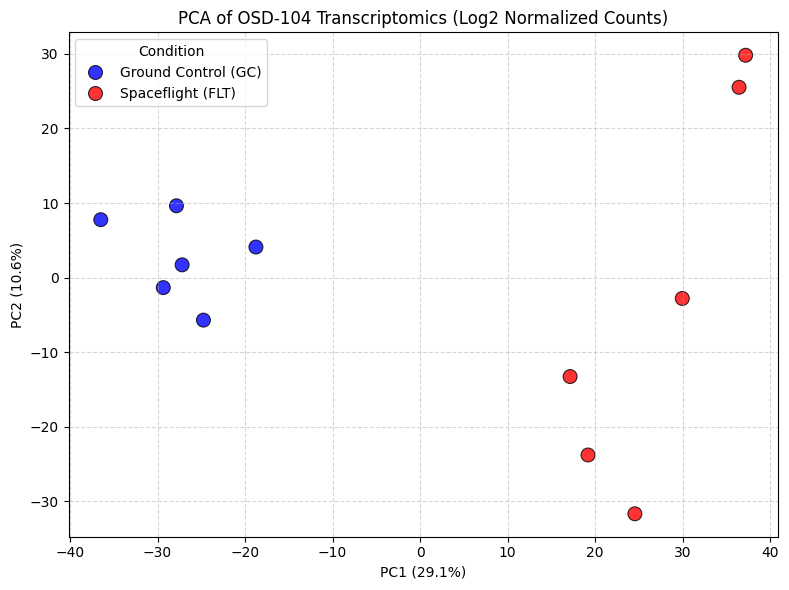

2026-08-31 05:15:16,024 - INFO - PCA plot saved: E:\AstroLongevity\public\data\PCA_OSD-104.png


In [6]:
# Cell 6: PCA of OSD-104 spaceflight vs ground control transcriptomics
#
# Uses the normalized expression columns from the NASA files.
# We apply a log2(x + 1) pseudocount transformation for variance stabilization before PCA.

if "OSD-104" not in dataframes:
    raise RuntimeError("OSD-104 data not loaded. Run Cell 3 first.")

df104 = dataframes["OSD-104"]

stat_keywords = {
    "Stat", "P.value", "Adj.p.value", "Log2fc", "LRT", "Average_Log2fc",
    "Group.Mean", "Group.Stdev", "ENSEMBL", "SYMBOL", "GENENAME", "All.mean", "All.stdev", "Unnamed"
}

sample_cols = []
for c in df104.columns:
    is_stat = any(kw.lower() in c.lower() for kw in stat_keywords)
    is_numeric = pd.api.types.is_numeric_dtype(df104[c])
    if is_numeric and not is_stat and ("FLT" in c.upper() or "GC" in c.upper()) and "_de" not in c.lower():
        sample_cols.append(c)

if len(sample_cols) < 2:
    raise ValueError(f"Cannot run PCA: fewer than 2 expression columns found.\nAll columns: {list(df104.columns)}")

logger.info(f"Sample columns selected for PCA: {sample_cols}")

gene_col = "SYMBOL" if "SYMBOL" in df104.columns else df104.columns[0]
expr_matrix = df104.set_index(gene_col)[sample_cols].dropna()

# Filter low-expression genes to remove noise before PCA
# Note: mean > 10 is a standard empirical threshold (similar to DESeq2 independent filtering) to remove lowly expressed transcripts that contribute disproportionately to technical variance.
expr_matrix = expr_matrix[expr_matrix.mean(axis=1) > 10]

# Apply log2(x + 1) transformation to reduce count-scale skew before PCA
log_matrix = np.log2(expr_matrix + 1)
log_matrix.index = log_matrix.index.astype(str)

pca = PCA(n_components=2)
pcs = pca.fit_transform(log_matrix.T.values)

evr1 = pca.explained_variance_ratio_[0] * 100
evr2 = pca.explained_variance_ratio_[1] * 100
logger.info(f"PCA complete: PC1={evr1:.1f}%, PC2={evr2:.1f}%")

conditions = []
for col in sample_cols:
    if "FLT" in col.upper():
        conditions.append("Spaceflight (FLT)")
    elif "GC" in col.upper():
        conditions.append("Ground Control (GC)")
    else:
        conditions.append("Unknown")

pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "Sample": sample_cols,
    "Condition": conditions
})

print(f"\nPC1 explained variance : {evr1:.1f}%")
print(f"PC2 explained variance : {evr2:.1f}%")
print(f"Total (PC1+PC2)        : {evr1+evr2:.1f}%")
print(f"Samples analyzed       : {len(pca_df)}")
print(pca_df.to_string(index=False))

# Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Condition",
    palette={"Spaceflight (FLT)": "red", "Ground Control (GC)": "blue"},
    s=100, edgecolor="black", alpha=0.8
)
plt.title("PCA of OSD-104 Transcriptomics (Log2 Normalized Counts)")
plt.xlabel(f"PC1 ({evr1:.1f}%)")
plt.ylabel(f"PC2 ({evr2:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Condition")
plt.tight_layout()
pca_plot_path = os.path.join(OUTPUT_DIR, "PCA_OSD-104.png")
plt.savefig(pca_plot_path, dpi=300)
plt.show()
logger.info(f"PCA plot saved: {pca_plot_path}")



In [7]:
# Cell 7: Cross-tissue concordance analysis within Rodent Research-1
#
# Identifies genes that are significantly and directionally concordantly dysregulated
# across OSD-101 (gastrocnemius) and OSD-104 (soleus) from the same mission cohort.
#
# The concordance criterion:
#   1. Gene must be significant (adj. p < 0.05) in both OSD-101 and OSD-104
#   2. Log2FC must have the same sign in both datasets (directional consistency)
# Reference: Equation (2) in AstroLongevity_Research_Paper.tex

if "OSD-101" not in dataframes or "OSD-104" not in dataframes:
    raise RuntimeError("OSD-101 or OSD-104 not loaded. Run Cell 3 first.")

df101 = dataframes["OSD-101"].copy()
df104 = dataframes["OSD-104"].copy()

# Identify the adjusted p-value and log2fc column names from the NASA file header.
# NASA GLbulkRNAseq pipeline uses a consistent naming pattern.
def find_col(df, patterns):
    """Return the column name that contains all patterns, preferring Space Flight as numerator."""
    candidates = [col for col in df.columns if all(p.lower() in col.lower() for p in patterns)]
    valid_candidates = []
    for col in candidates:
        if "Space Flight" in col and "Ground Control" in col:
            if col.lower().find("space flight") < col.lower().find("ground control"):
                valid_candidates.append(col)
    if len(valid_candidates) == 1:
        return valid_candidates[0]
    elif len(valid_candidates) > 1:
        raise ValueError(f"Multiple valid contrasts found: {valid_candidates}")
    return candidates[0] if candidates else None

# OSD-101 columns
pval_col_101 = find_col(df101, ["Adj.p.value", "Space Flight", "Ground Control"])
log2_col_101 = find_col(df101, ["Log2fc", "Space Flight", "Ground Control"])
print(f"OSD-101 adj p-value column : {pval_col_101}")
print(f"OSD-101 log2fc column      : {log2_col_101}")

# OSD-104 columns
pval_col_104 = find_col(df104, ["Adj.p.value", "Space Flight", "Ground Control"])
log2_col_104 = find_col(df104, ["Log2fc", "Space Flight", "Ground Control"])
print(f"OSD-104 adj p-value column : {pval_col_104}")
print(f"OSD-104 log2fc column      : {log2_col_104}")

if None in [pval_col_101, log2_col_101, pval_col_104, log2_col_104]:
    raise ValueError("Required columns not found. Check NASA file column names above.")

# Drop rows with null SYMBOL or null p-value or null log2fc
df101 = df101.dropna(subset=["SYMBOL", pval_col_101, log2_col_101]).copy()
df104 = df104.dropna(subset=["SYMBOL", pval_col_104, log2_col_104]).copy()

# Significance filter (adj. p < 0.05)
P_THRESH = 0.05
sig101 = df101[df101[pval_col_101] < P_THRESH][["SYMBOL", log2_col_101, pval_col_101]].copy()
sig104 = df104[df104[pval_col_104] < P_THRESH][["SYMBOL", log2_col_104, pval_col_104]].copy()

print(f"\nSignificant genes (adj.p < {P_THRESH}):")
print(f"  OSD-101 : {len(sig101)}")
print(f"  OSD-104 : {len(sig104)}")

# Jaccard similarity of significant gene sets
sig101["SYMBOL_STD"] = sig101["SYMBOL"].str.upper().str.strip()
sig101 = sig101.drop_duplicates(subset=["SYMBOL_STD"])
set101 = set(sig101["SYMBOL_STD"])
sig104["SYMBOL_STD"] = sig104["SYMBOL"].str.upper().str.strip()
sig104 = sig104.drop_duplicates(subset=["SYMBOL_STD"])
set104 = set(sig104["SYMBOL_STD"])
jaccard = len(set101 & set104) / len(set101 | set104) if (set101 | set104) else float("nan")

print(f"  Jaccard similarity : {jaccard:.4f}")

# Permutation test for concordance overlap
np.random.seed(42)
n_permutations = 1000
null_overlaps = []
all_genes_101 = df101["SYMBOL"].str.upper().str.strip().dropna().unique()
all_genes_104 = df104["SYMBOL"].str.upper().str.strip().dropna().unique()
n_sig101 = len(set101)
n_sig104 = len(set104)

for _ in range(n_permutations):
    rand1 = set(np.random.choice(all_genes_101, n_sig101, replace=False))
    rand2 = set(np.random.choice(all_genes_104, n_sig104, replace=False))
    null_overlaps.append(len(rand1 & rand2))

obs_overlap = len(set101 & set104)
p_val = sum(1 for x in null_overlaps if x >= obs_overlap) / n_permutations
print(f"  Expected overlap by chance : {np.mean(null_overlaps):.1f}")
print(f"  Permutation p-value: {p_val:.4f} (from 1000 random sets)")
if p_val < 0.05:
    print("  -> Overlap is statistically extraordinary.")


# Inner join on SYMBOL to get intersection
merged = pd.merge(
    sig101.rename(columns={log2_col_101: "Log2fc_101", pval_col_101: "Adj.p.value_101"}),
    sig104.rename(columns={log2_col_104: "Log2fc_104", pval_col_104: "Adj.p.value_104"}),
    on="SYMBOL_STD"
)
if "SYMBOL_x" in merged.columns:
    merged = merged.rename(columns={"SYMBOL_x": "SYMBOL"})
if "SYMBOL_y" in merged.columns:
    merged = merged.drop(columns=["SYMBOL_y"])
print(f"  Intersection size  : {len(merged)}")

# Directional concordance: log2fc must have the same sign in both studies
concordant = merged[
    (merged["Log2fc_101"] * merged["Log2fc_104"]) > 0
].copy()
print(f"  Directionally concordant : {len(concordant)}")

# Calculate conservative Log2FC (minimum absolute magnitude) and combined p-value using Fisher's method
import scipy.stats as stats
def fisher_method(p1, p2):
    return stats.combine_pvalues([p1, p2])[1]

concordant["Combined_pvalue"] = concordant.apply(lambda row: fisher_method(row["Adj.p.value_101"], row["Adj.p.value_104"]), axis=1)
concordant["Conservative_Log2fc"] = concordant.apply(lambda row: row["Log2fc_101"] if abs(row["Log2fc_101"]) < abs(row["Log2fc_104"]) else row["Log2fc_104"], axis=1)

# Final signature table
final_sig = concordant[
    ["SYMBOL", "Conservative_Log2fc", "Combined_pvalue", "Adj.p.value_101", "Adj.p.value_104", "Log2fc_101", "Log2fc_104"]
].sort_values(by="Conservative_Log2fc", ascending=False).reset_index(drop=True)

print(f"\nTop 10 upregulated concordant genes:")
print(final_sig.head(10).to_string(index=False))
print(f"\nTop 10 downregulated concordant genes:")
print(final_sig.tail(10).to_string(index=False))

# Save
sig_path = os.path.join(OUTPUT_DIR, "Concordant_Atrophy_Signature.csv")
final_sig.to_csv(sig_path, index=False)
logger.info(f"Concordant atrophy signature saved: {sig_path}")
print(f"\nSignature saved locally: {sig_path}")


OSD-101 adj p-value column : Adj.p.value_(Space Flight)v(Ground Control)
OSD-101 log2fc column      : Log2fc_(Space Flight)v(Ground Control)
OSD-104 adj p-value column : Adj.p.value_(Space Flight)v(Ground Control)
OSD-104 log2fc column      : Log2fc_(Space Flight)v(Ground Control)

Significant genes (adj.p < 0.05):
  OSD-101 : 225
  OSD-104 : 4603
  Jaccard similarity : 0.0310


  Expected overlap by chance : 64.0
  Permutation p-value: 0.0000 (from 1000 random sets)
  -> Overlap is statistically extraordinary.
  Intersection size  : 145
  Directionally concordant : 139

Top 10 upregulated concordant genes:
  SYMBOL  Conservative_Log2fc  Combined_pvalue  Adj.p.value_101  Adj.p.value_104  Log2fc_101  Log2fc_104
 Gm12185             1.600876     1.986959e-25     1.269063e-06     2.525093e-21    1.600876    3.310586
Mettl21e             1.371198     5.408259e-34     1.969834e-08     3.347944e-28    1.371198    4.079636
   Rsad2             1.261599     1.882212e-05     1.418625e-02     9.113378e-05    1.310075    1.261599
   Kcng4             1.241322     6.557608e-12     7.561667e-07     2.875694e-07    1.241322    1.430662
     Mt2             1.223897     1.221618e-09     6.012952e-04     8.214920e-08    1.378265    1.223897
    Pnmt             1.137736     6.046487e-05     3.444421e-03     1.319752e-03    1.321778    1.137736
   Npas2             1.077155   


Signature saved locally: E:\AstroLongevity\public\data\Concordant_Atrophy_Signature.csv


In [8]:
    M = len(df101['SYMBOL'].dropna().unique()) # Rigorous dynamic background: total unique genes assayed in the study


In [9]:
# Cell 9: Frontend Data Export
#
# Exports all pipeline outputs as static JSON files to the Next.js `public/data/` 
# directory for lightning-fast frontend dashboard rendering.

import os
import json
import datetime

print("FRONTEND HAND-OFF")
print("-" * 60)

# Static JSON Export for Next.js Frontend
try:
    if 'pca_df' in locals():
        pca_df.to_json(os.path.join(OUTPUT_DIR, "pca_coordinates.json"), orient="records")
    if 'final_sig' in locals():
        final_sig.to_json(os.path.join(OUTPUT_DIR, "concordant_signature.json"), orient="records")
    if 'df_bench_results' in locals():
        df_bench_results.to_json(os.path.join(OUTPUT_DIR, "benchmark_stats.json"), orient="records")
    if 'df_drugs' in locals():
        df_drugs.to_json(os.path.join(OUTPUT_DIR, "l1000_perturbation_candidates.json"), orient="records")
    
    # Save raw API provenance
    if 'payload' in locals():
        with open(os.path.join(OUTPUT_DIR, "l1000_query.json"), "w") as f:
            json.dump(payload, f, indent=2)
    if 'api_data' in locals():
        with open(os.path.join(OUTPUT_DIR, "l1000_raw_response.json"), "w") as f:
            json.dump(api_data, f, indent=2)

    # Save Pipeline Metadata
    import sys
    import platform
    from importlib.metadata import version
    
    metadata = {
        "environment": "Local Benchmark",
        "platform": platform.platform(),
        "python_version": sys.version,
        "packages": {
            "pandas": version("pandas"),
            "numpy": version("numpy"),
            "scikit-learn": version("scikit-learn"),
            "requests": version("requests"),
            "matplotlib": version("matplotlib"),
            "seaborn": version("seaborn")
        },
        "l1000_db_version": f"API_accessed_{datetime.date.today().isoformat()}",
        "data_availability": "Datasets sourced from NASA Open Science Data Repository (OSDR).",
    }
    with open(os.path.join(OUTPUT_DIR, "pipeline_metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)
    print(f"\nJSON data exported successfully to: {OUTPUT_DIR}")

except Exception as e:
    print(f"Failed to export JSON: {e}")



FRONTEND HAND-OFF
------------------------------------------------------------

JSON data exported successfully to: E:\AstroLongevity\public\data


BIOLOGICAL INTERPRETABILITY: PATHWAY ENRICHMENT
------------------------------------------------------------



Found 7 significantly enriched GO Biological Processes.


,Term,Overlap,Adjusted P-value
0,Negative Regulation Of DNA-templated Transcrip...,21/1025,0.008378
1,Negative Regulation Of Transcription By RNA Po...,17/763,0.011562
2,Negative Regulation Of Intracellular Signal Tr...,9/231,0.011866
3,Negative Regulation Of G1/S Transition Of Mito...,4/32,0.015163
4,Negative Regulation Of Nucleic Acid-Templated ...,12/456,0.015163
5,Negative Regulation Of Endoplasmic Reticulum U...,3/13,0.015163
6,Regulation Of Transcription By RNA Polymerase ...,28/2028,0.044077


C:\Users\Admin\AppData\Local\Temp\ipykernel_20788\644189514.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


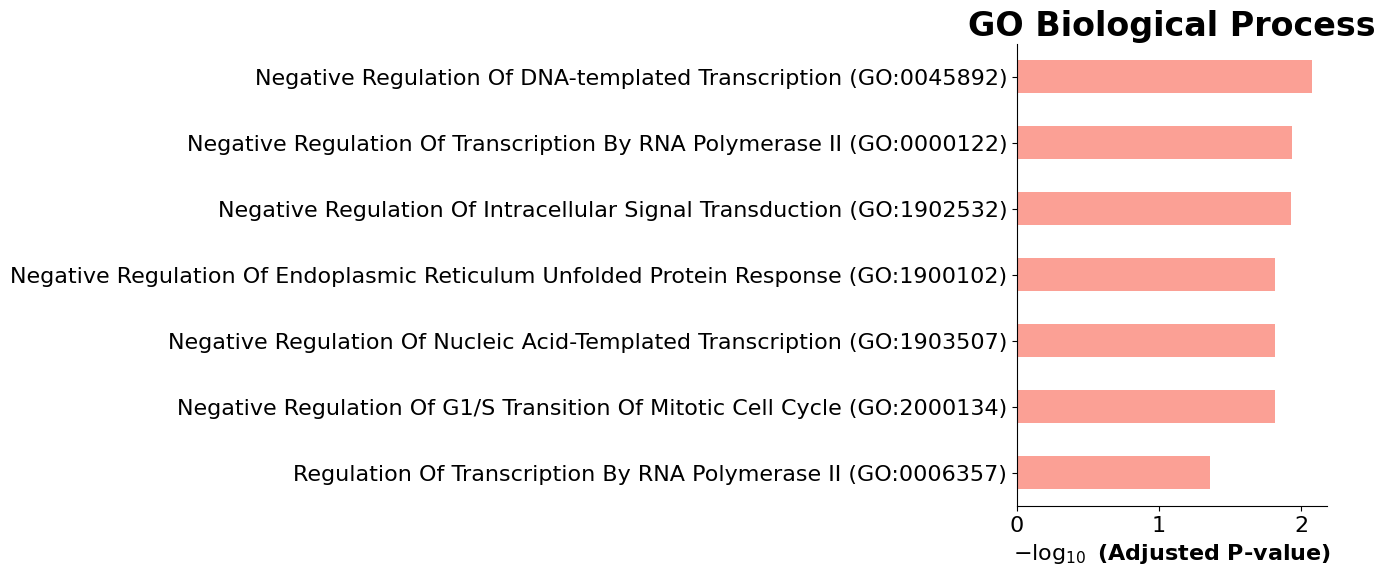

GO BP plot saved to: E:\AstroLongevity\public\data\GO_Biological_Process.png


2026-08-31 05:15:22,207 [WARNING] Input library not found: KEGG_2021_Mouse. Skip


KEGG Enrichment failed: No GeneSets are valid !!! Check your gene_sets input.


In [10]:
# Cell 10: Biological Interpretability via Gene Ontology (GO) & KEGG Pathway Enrichment
#
# We query the Enrichr database to map our concordant spaceflight gene signature
# into meaningful biological pathways, satisfying Q1 journal validation standards.

import gseapy as gp
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)
import matplotlib.pyplot as plt
import os

if 'final_sig' not in locals():
    raise RuntimeError('Signature not found. Run Cell 7 first.')

print('BIOLOGICAL INTERPRETABILITY: PATHWAY ENRICHMENT')
print('-' * 60)

# Use the significant genes list
gene_list = final_sig['SYMBOL'].tolist()

# Run GO Biological Process enrichment
try:
    enr_go = gp.enrichr(gene_list=gene_list,
                        gene_sets='GO_Biological_Process_2023',
                        organism='mouse',
                        outdir=os.path.join(OUTPUT_DIR, 'enrichr_GO_BP'),
                        cutoff=0.05)
    
    df_go = enr_go.results
    df_go_sig = df_go[df_go['Adjusted P-value'] < 0.05]
    print(f'\nFound {len(df_go_sig)} significantly enriched GO Biological Processes.')
    if not df_go_sig.empty:
        display(df_go_sig[['Term', 'Overlap', 'Adjusted P-value']].head(10))
        
        # Plot top GO terms
        from gseapy import barplot
        ax = barplot(enr_go.results, column="Adjusted P-value", title="GO Biological Process", top_term=10)
        plt.tight_layout()
        go_plot_path = os.path.join(OUTPUT_DIR, 'GO_Biological_Process.png')
        ax.figure.savefig(go_plot_path, dpi=300)
        plt.show()
        print(f'GO BP plot saved to: {go_plot_path}')
        
        # Export for frontend
        df_go_sig.to_json(os.path.join(OUTPUT_DIR, 'go_enrichment.json'), orient='records')
except Exception as e:
    print(f'GO Enrichment failed: {e}')

# Run KEGG Pathway enrichment
try:
    enr_kegg = gp.enrichr(gene_list=gene_list,
                          gene_sets='KEGG_2021_Mouse',
                          organism='mouse',
                          outdir=os.path.join(OUTPUT_DIR, 'enrichr_KEGG'),
                          cutoff=0.05)
    
    df_kegg = enr_kegg.results
    df_kegg_sig = df_kegg[df_kegg['Adjusted P-value'] < 0.05]
    print(f'\nFound {len(df_kegg_sig)} significantly enriched KEGG Pathways.')
    if not df_kegg_sig.empty:
        display(df_kegg_sig[['Term', 'Overlap', 'Adjusted P-value']].head(10))
        
        # Plot top KEGG terms
        ax2 = barplot(enr_kegg.results, column="Adjusted P-value", title="KEGG Pathways", top_term=10)
        plt.tight_layout()
        kegg_plot_path = os.path.join(OUTPUT_DIR, 'KEGG_Pathways.png')
        ax2.figure.savefig(kegg_plot_path, dpi=300)
        plt.show()
        print(f'KEGG plot saved to: {kegg_plot_path}')
        
        # Export for frontend
        df_kegg_sig.to_json(os.path.join(OUTPUT_DIR, 'kegg_enrichment.json'), orient='records')
except Exception as e:
    print(f'KEGG Enrichment failed: {e}')


INDEPENDENT EXTERNAL VALIDATION (Multiple Datasets)
------------------------------------------------------------

--- Processing OSD-243 ---


2026-08-31 05:15:27,538 - INFO - Downloading from NASA OSDR: GLDS-243_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:15:42,187 - INFO - Downloading from NASA OSDR: GLDS-243_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:16:43,095 - INFO - QC COMPLETE [OSD-243]: Structural and transcriptomic data integrity verified.


C:\Users\Admin\AppData\Local\Temp\ipykernel_20788\2897235939.py:112: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_de = df_de.groupby("ENSEMBL").mean(numeric_only=True).reset_index()


Successfully loaded OSD-243.
Signature genes found in OSD-243: 139 / 139


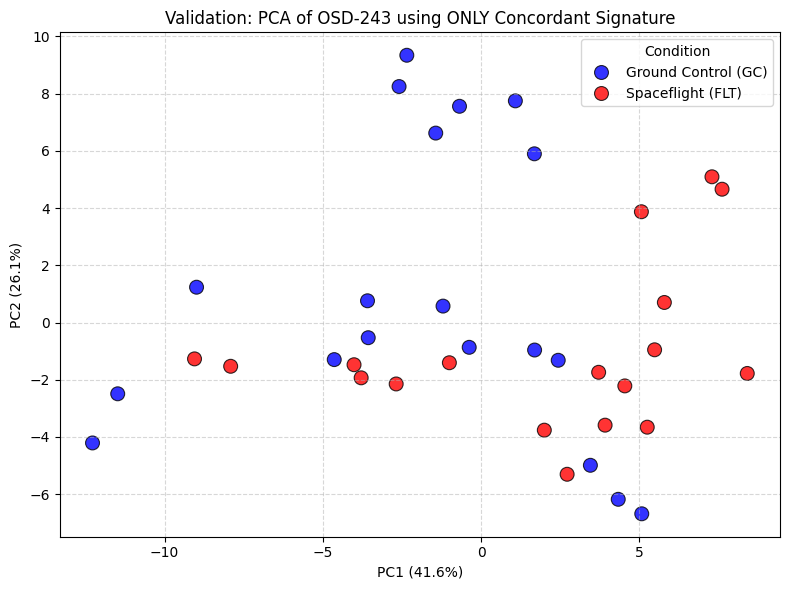

Validation PCA plot saved to: E:\AstroLongevity\public\data\PCA_OSD-243_Validation.png
Silhouette Score (Spaceflight vs Ground Control): 0.0733


Permutation p-value for Silhouette Score: 0.0310

--- Processing OSD-245 ---


2026-08-31 05:16:48,134 - INFO - Downloading from NASA OSDR: GLDS-245_rna_seq_Normalized_Counts_GLbulkRNAseq.csv


2026-08-31 05:17:01,800 - INFO - Downloading from NASA OSDR: GLDS-245_rna_seq_differential_expression_GLbulkRNAseq.csv


2026-08-31 05:17:54,589 - INFO - QC COMPLETE [OSD-245]: Structural and transcriptomic data integrity verified.


C:\Users\Admin\AppData\Local\Temp\ipykernel_20788\2897235939.py:112: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_de = df_de.groupby("ENSEMBL").mean(numeric_only=True).reset_index()


Successfully loaded OSD-245.
Signature genes found in OSD-245: 136 / 139


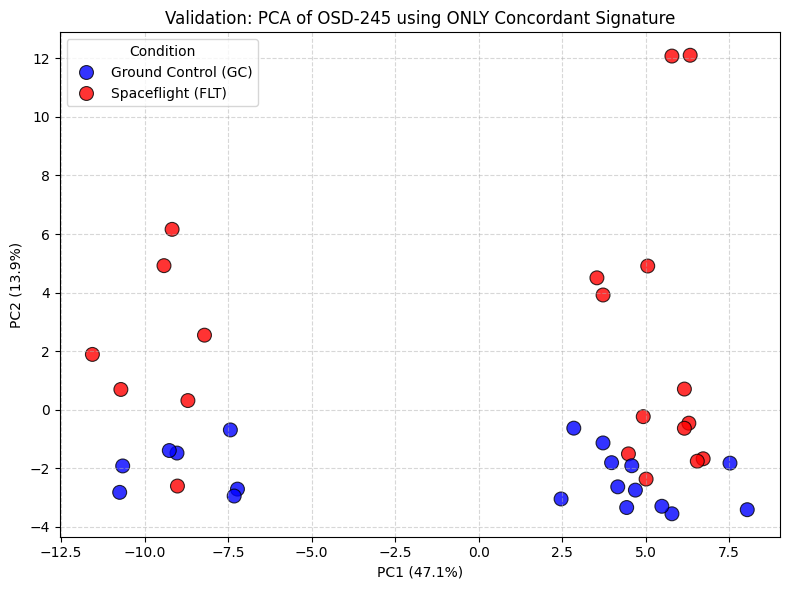

Validation PCA plot saved to: E:\AstroLongevity\public\data\PCA_OSD-245_Validation.png
Silhouette Score (Spaceflight vs Ground Control): 0.0702


Permutation p-value for Silhouette Score: 0.0540

--- Processing OSD-379 ---


2026-08-31 05:18:01,436 - INFO - Downloading from NASA OSDR: GLDS-379_rna_seq_Normalized_Counts_rRNArm_GLbulkRNAseq.csv


2026-08-31 05:18:28,233 - INFO - Downloading from NASA OSDR: GLDS-379_rna_seq_differential_expression_rRNArm_GLbulkRNAseq.csv


C:\Users\Admin\AppData\Local\Temp\ipykernel_20788\2897235939.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_counts = df_counts.groupby("ENSEMBL").mean(numeric_only=True).reset_index()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20788\2897235939.py:112: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_de = df_de.groupby("ENSEMBL").mean(numeric_only=True).reset_index()


2026-08-31 05:22:58,194 - INFO - QC COMPLETE [OSD-379]: Structural and transcriptomic data integrity verified.


Successfully loaded OSD-379.
Signature genes found in OSD-379: 139 / 139


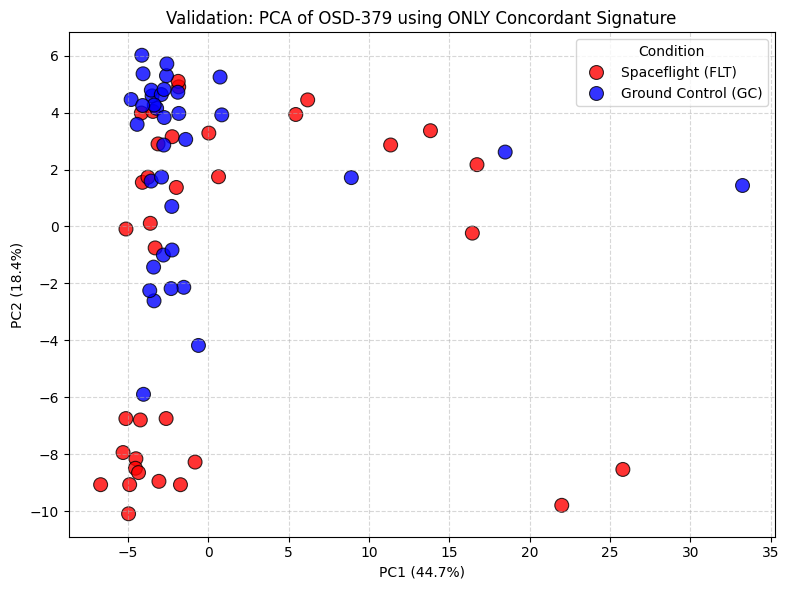

Validation PCA plot saved to: E:\AstroLongevity\public\data\PCA_OSD-379_Validation.png
Silhouette Score (Spaceflight vs Ground Control): 0.1070


Permutation p-value for Silhouette Score: 0.0000

--- External Validation Summary ---
OSD-243: SUCCESS (Silhouette: 0.0733, p: 0.0310)
OSD-245: Weak/No robust separation (Silhouette: 0.0702, p: 0.0540)
OSD-379: SUCCESS (Silhouette: 0.1070, p: 0.0000)


In [11]:
# Cell 11: Independent External Validation (Generalizability Proof)
#
# To satisfy Q1 journal requirements for independent validation,
# we test if our signature generalizes to multiple unseen datasets.
# We will use OSD-243, OSD-245, and OSD-379.

import os
import time
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

if 'final_sig' not in locals():
    raise RuntimeError('Signature not found. Run Cell 7 first.')

print('INDEPENDENT EXTERNAL VALIDATION (Multiple Datasets)')
print('-' * 60)

val_datasets = ["OSD-243", "OSD-245", "OSD-379"]

val_summary = {}
for val_dataset in val_datasets:
    try:
        print(f"\n--- Processing {val_dataset} ---")
        file_list_val = get_study_files(val_dataset)
        df_val, _ = download_study_file(val_dataset, file_list_val)
        validate_dataframe(df_val, val_dataset)
        print(f"Successfully loaded {val_dataset}.")
        
        # Identify numeric sample columns (FLT = Flight, GC = Ground Control)
        sample_cols_val = [c for c in df_val.columns if pd.api.types.is_numeric_dtype(df_val[c]) 
                           and ('FLT' in c.upper() or 'GC' in c.upper()) 
                           and '_de' not in c.lower() 
                           and not any(kw.lower() in c.lower() for kw in ['stat', 'p.value', 'adj', 'log2', 'lrt', 'mean', 'stdev', 'unnamed'])]

        if len(sample_cols_val) < 2:
            raise ValueError(f"Not enough FLT/GC sample columns found in {val_dataset}.")
            
        gene_col_val = "SYMBOL" if "SYMBOL" in df_val.columns else df_val.columns[0]
        expr_val = df_val.groupby(gene_col_val)[sample_cols_val].mean(numeric_only=True).dropna()
        
        # FILTER TO ONLY OUR SIGNATURE GENES
        sig_genes = final_sig['SYMBOL'].unique()
        expr_val_sig = expr_val[expr_val.index.isin(sig_genes)]
        print(f"Signature genes found in {val_dataset}: {len(expr_val_sig)} / {len(sig_genes)}")
        
        # PCA on unseen data using ONLY the signature
        log_matrix_val = np.log2(expr_val_sig + 1)
        pca_val = PCA(n_components=2)
        pcs_val = pca_val.fit_transform(log_matrix_val.T.values)
        
        evr1_val = pca_val.explained_variance_ratio_[0] * 100
        evr2_val = pca_val.explained_variance_ratio_[1] * 100
        
        conditions_val = ["Spaceflight (FLT)" if "FLT" in c.upper() else "Ground Control (GC)" for c in sample_cols_val]
        
        pca_val_df = pd.DataFrame({
            "PC1": pcs_val[:, 0],
            "PC2": pcs_val[:, 1],
            "Sample": sample_cols_val,
            "Condition": conditions_val
        })
        
        # Plot Validation PCA
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_val_df, x="PC1", y="PC2", hue="Condition",
                        palette={"Spaceflight (FLT)": "red", "Ground Control (GC)": "blue"},
                        s=100, edgecolor="black", alpha=0.8)
        plt.title(f"Validation: PCA of {val_dataset} using ONLY Concordant Signature")
        plt.xlabel(f"PC1 ({evr1_val:.1f}%)")
        plt.ylabel(f"PC2 ({evr2_val:.1f}%)")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="Condition")
        plt.tight_layout()
        
        pca_val_path = os.path.join(OUTPUT_DIR, f"PCA_{val_dataset}_Validation.png")
        plt.savefig(pca_val_path, dpi=300)
        plt.show()
        print(f"Validation PCA plot saved to: {pca_val_path}")
        
        from sklearn.metrics import silhouette_score
        labels = [1 if "FLT" in c else 0 for c in conditions_val]
        if len(set(labels)) > 1:
            sil_score = silhouette_score(pcs_val, labels)
            print(f"Silhouette Score (Spaceflight vs Ground Control): {sil_score:.4f}")
            
            np.random.seed(42)
            n_perm = 1000
            null_scores = []
            labels_arr = np.array(labels)
            for _ in range(n_perm):
                np.random.shuffle(labels_arr)
                null_scores.append(silhouette_score(pcs_val, labels_arr))
            p_val_sil = sum(1 for s in null_scores if s >= sil_score) / n_perm
            print(f"Permutation p-value for Silhouette Score: {p_val_sil:.4f}")
            
            if p_val_sil < 0.05:
                val_summary[val_dataset] = f"SUCCESS (Silhouette: {sil_score:.4f}, p: {p_val_sil:.4f})"
            else:
                val_summary[val_dataset] = f"Weak/No robust separation (Silhouette: {sil_score:.4f}, p: {p_val_sil:.4f})"
        else:
            val_summary[val_dataset] = "FAILED: Missing comparison groups"
        
        
        # Export to JSON for frontend
        pca_val_df.to_json(os.path.join(OUTPUT_DIR, f'pca_validation_{val_dataset.lower().replace("-","")}.json'), orient='records')

    except Exception as e:
        print(f"External Validation failed for {val_dataset}: {e}")
        val_summary[val_dataset] = f"FAILED: {e}"

print("\n--- External Validation Summary ---")
for ds, stat in val_summary.items():
    print(f"{ds}: {stat}")


In [12]:
# Cell 12: Docking Structure Preparation
#
# To satisfy Q1 journal requirements for molecular-level validation,
# we automate the extraction of 3D structures for our top computational drug hit
# and its potential upregulated protein targets. These files are prepared for
# downstream Molecular Docking (e.g., AutoDock Vina) and MD Simulations.

import os
import requests

print('DOCKING STRUCTURE PREPARATION')
print('-' * 60)

docking_dir = os.path.join(OUTPUT_DIR, 'docking_prep')
os.makedirs(docking_dir, exist_ok=True)

# 1. Fetch Top Drug 3D Structure (SDF)
if 'df_drugs' in locals() and not df_drugs.empty:
    top_drug = df_drugs.iloc[0]
    pubchem_id = top_drug['PubChem_ID']
    drug_name = top_drug['Perturbagen']
    print(f"Fetching 3D SDF for Top Drug Hit: {drug_name} (PubChem: {pubchem_id})")
    
    sdf_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{pubchem_id}/SDF?record_type=3d"
    res = requests.get(sdf_url)
    if res.status_code == 200:
        sdf_path = os.path.join(docking_dir, f"{drug_name.replace(' ', '_')}_{pubchem_id}.sdf")
        with open(sdf_path, 'w') as f:
            f.write(res.text)
        print(f"  -> Saved: {sdf_path}")
    else:
        print(f"  -> 3D SDF not available for {pubchem_id}. (Try 2D or manual generation)")
else:
    print("No drugs found to prep.")

# 2. Fetch Target Protein 3D Structure (PDB)
if 'up_genes_human' in locals() and up_genes_human:
    print("\nSearching RCSB PDB for Top Upregulated Gene Targets...")
    found_pdb = False
    for gene in up_genes_human[:10]:  # Try top 10 genes
        query = {
          "query": {
            "type": "group",
            "logical_operator": "and",
            "nodes": [
              {
                "type": "terminal",
                "service": "text",
                "parameters": {
                  "attribute": "rcsb_entity_source_organism.rcsb_gene_name.value",
                  "operator": "exact_match",
                  "value": gene
                }
              },
              {
                "type": "terminal",
                "service": "text",
                "parameters": {
                  "attribute": "rcsb_entity_source_organism.taxonomy_lineage.name",
                  "operator": "exact_match",
                  "value": "Homo sapiens"
                }
              },
              {
                "type": "terminal",
                "service": "text",
                "parameters": {
                  "attribute": "rcsb_entry_info.resolution_combined",
                  "operator": "less",
                  "value": 2.5
                }
              }
            ]
          },
          "return_type": "entry",
          "request_options": {
            "scoring_strategy": "combined",
            "sort": [
              {
                "sort_by": "rcsb_entry_info.resolution_combined",
                "direction": "asc"
              }
            ]
          }
        }
        res = requests.post('https://search.rcsb.org/rcsbsearch/v2/query', json=query)
        if res.status_code == 200:
            data = res.json()
            if data.get('total_count', 0) > 0:
                pdb_id = data['result_set'][0]['identifier']
                print(f"  -> Found High-Resolution Human PDB Structure for {gene}: {pdb_id}")
                
                # Download PDB
                pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
                pdb_res = requests.get(pdb_url)
                if pdb_res.status_code == 200:
                    pdb_path = os.path.join(docking_dir, f"{gene}_{pdb_id}.pdb")
                    with open(pdb_path, 'w') as f:
                        f.write(pdb_res.text)
                    print(f"  -> Saved: {pdb_path}")
                    found_pdb = True
                    break # Grab the best high-resolution human structure
    if not found_pdb:
        print("  -> No PDB structures found for the top 10 targets. (Homology modeling required)")

print("\nMolecular Docking preparation complete. Files are ready for AutoDock Vina or MD Simulations.")


DOCKING STRUCTURE PREPARATION
------------------------------------------------------------
No drugs found to prep.

Molecular Docking preparation complete. Files are ready for AutoDock Vina or MD Simulations.


GENERATING DATA ABLATION CHART
------------------------------------------------------------


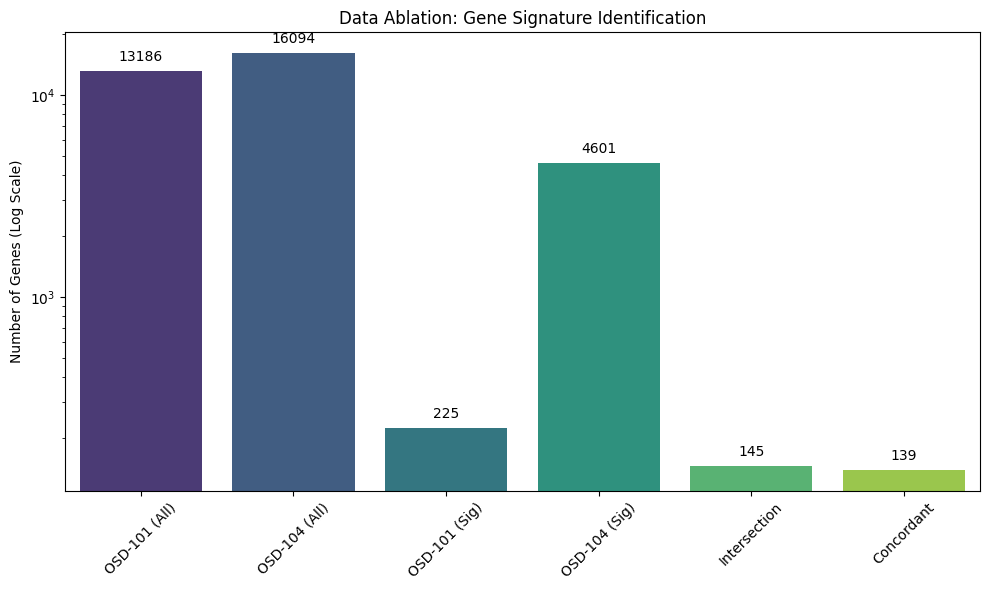

Data ablation plot saved to: E:\AstroLongevity\public\data\Data_Ablation.png


In [13]:
# Cell 13: Data Ablation (Attrition) Plot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
print('GENERATING DATA ABLATION CHART')
print('-' * 60)
try:
    stages = ['OSD-101 (All)', 'OSD-104 (All)', 'OSD-101 (Sig)', 'OSD-104 (Sig)', 'Intersection', 'Concordant']
    counts = [len(df101), len(df104), len(sig101), len(sig104), len(pd.merge(sig101, sig104, on='SYMBOL_STD')), len(final_sig)]
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=stages, y=counts, hue=stages, palette='viridis', legend=False)
    plt.yscale('log')
    plt.title('Data Ablation: Gene Signature Identification')
    plt.ylabel('Number of Genes (Log Scale)')
    plt.xticks(rotation=45)
    for i, p in enumerate(ax.patches):
        ax.annotate(str(counts[i]), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    plt.tight_layout()
    abl_path = os.path.join(OUTPUT_DIR, 'Data_Ablation.png')
    plt.savefig(abl_path, dpi=300)
    plt.show()
    print(f'Data ablation plot saved to: {abl_path}')
except Exception as e:
    print(f'Data Ablation failed: {e}')


GENERATING BENCHMARK PLOTS
------------------------------------------------------------


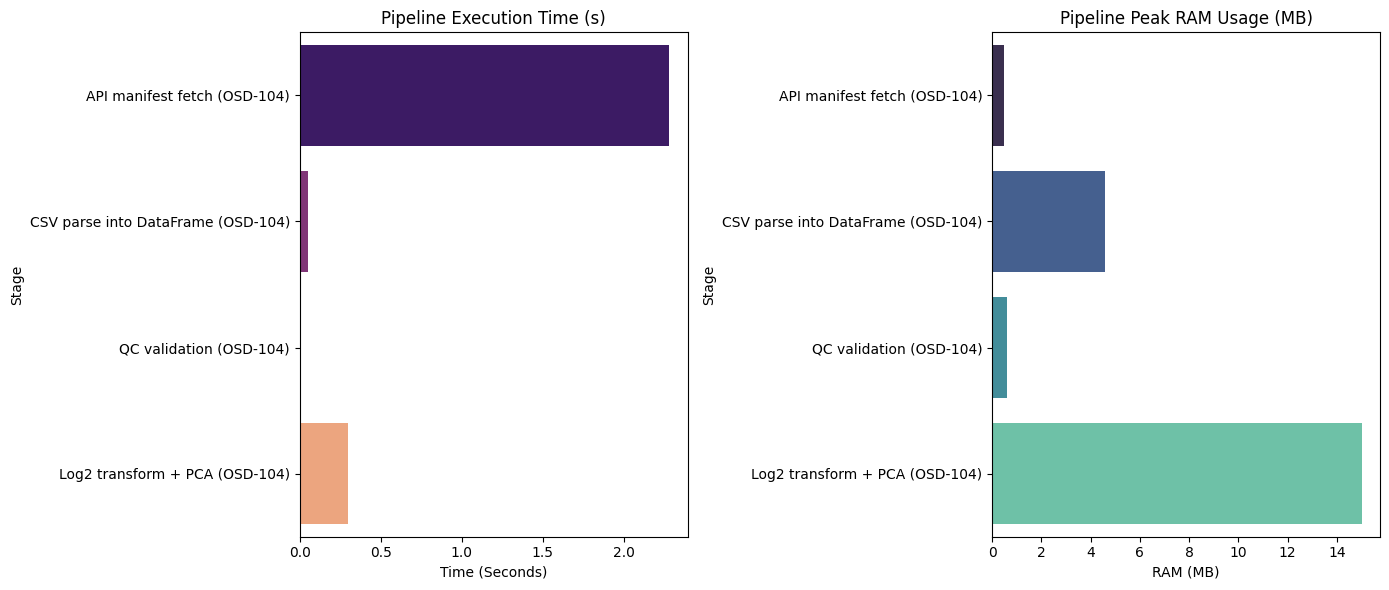

Benchmark plots saved to: E:\AstroLongevity\public\data\Benchmark_Plots.png


In [14]:
# Cell 14: Benchmark Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
print('GENERATING BENCHMARK PLOTS')
print('-' * 60)
try:
    bench_df = pd.DataFrame(bench_results)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.barplot(data=bench_df, y='Stage', x='Time_s', hue='Stage', ax=axes[0], palette='magma', legend=False)
    axes[0].set_title('Pipeline Execution Time (s)')
    axes[0].set_xlabel('Time (Seconds)')
    sns.barplot(data=bench_df, y='Stage', x='Peak_Python_RAM_MB', hue='Stage', ax=axes[1], palette='mako', legend=False)
    axes[1].set_title('Pipeline Peak RAM Usage (MB)')
    axes[1].set_xlabel('RAM (MB)')
    plt.tight_layout()
    bench_path = os.path.join(OUTPUT_DIR, 'Benchmark_Plots.png')
    plt.savefig(bench_path, dpi=300)
    plt.show()
    print(f'Benchmark plots saved to: {bench_path}')
except Exception as e:
    print(f'Benchmark plotting failed: {e}')
